# 07 · Parâmetros, escala e outras famílias — *Cristiane*

Perguntas:
1. Por que o GPT-2 tem esses valores? De onde surgiram?
2. Quais as diferenças entre small, medium, large e XL?
3. E se eu escalar tudo por 3? E se eu quiser chegar no GPT-3?
4. O que é e onde entra o **viés** do modelo? E o **gradiente**?
5. Llama, Claude, GPT-4/5… usam a mesma base?

Os modelos grandes são criados no device `meta`: só formato, sem alocar memória — dá para "instanciar" até o GPT-3.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import tiktoken
import torch

from aula import GPT_CONFIG_124M, GPT2_SIZES, device, load_gpt2, n_params
from llms_from_scratch.ch04 import GPTModel

bpe = tiktoken.get_encoding("gpt2")
COMPARAR_355M = False  # 🔧 True baixa o GPT-2 medium (~1,4 GB) para comparar texto gerado


def contar(cfg):
    with torch.device("meta"):
        m = GPTModel(cfg)
    total = n_params(m)
    return {
        "params (M)": total / 1e6,
        "sem out_head (M)": (total - m.out_head.weight.numel()) / 1e6,  # GPT-2 original compartilha pesos com tok_emb
        "embeddings (M)": (m.tok_emb.weight.numel() + m.pos_emb.weight.numel()) / 1e6,
        "blocos (M)": sum(p.numel() for p in m.trf_blocks.parameters()) / 1e6,
        "float32 (GB)": total * 4 / 1e9,
        "treino Adam ≈ (GB)": total * 16 / 1e9,  # pesos + gradientes + 2 estados do Adam, sem ativações
    }

## 1. As quatro versões do GPT-2

In [2]:
linhas = []
for nome, tam in GPT2_SIZES.items():
    cfg = {**GPT_CONFIG_124M, **tam}
    linhas.append({"modelo": f"GPT-2 {nome}", **tam, "head_dim": tam["emb_dim"] // tam["n_heads"], **contar(cfg)})
tabela = pd.DataFrame(linhas).set_index("modelo")
tabela.round(1)

,emb_dim,n_layers,n_heads,head_dim,params (M),sem out_head (M),embeddings (M),blocos (M),float32 (GB),treino Adam ≈ (GB)
modelo,,,,,,,,,,
GPT-2 124M,768,12,12,64,163.0,124.4,39.4,85.0,0.7,2.6
GPT-2 355M,1024,24,16,64,406.2,354.7,52.5,302.2,1.6,6.5
GPT-2 774M,1280,36,20,64,838.2,773.9,65.6,708.2,3.4,13.4
GPT-2 1558M,1600,48,25,64,1637.8,1557.4,82.0,1475.3,6.6,26.2


- O nome (124M, 355M…) conta os parâmetros **com** weight tying (`sem out_head`).
- **head_dim é sempre 64**: a OpenAI cresceu largura e profundidade juntas mantendo cada cabeça do mesmo tamanho.
- A fatia de embeddings cai de ~30% (small) para ~5% (XL): em modelos grandes quase tudo está nos blocos.

## 2. De onde vêm esses números?
| valor | origem |
|---|---|
| `vocab_size = 50257` | 256 bytes + 50.000 merges de BPE + `<|endoftext|>` |
| `context_length = 1024` | dobro do GPT-1 (512); atenção é O(n²) em memória, era o que cabia nas GPUs de 2019 |
| `emb_dim = 768`, 12 camadas, 12 heads | herdado do GPT-1 / BERT-base (que por sua vez veio do Transformer "base" 512 → 768) |
| FFN = 4 × `emb_dim` | proporção do Transformer original (512 → 2048) |
| tamanhos maiores | escolhidos para testar *scaling*: ~3× parâmetros a cada passo, head_dim fixo em 64 |

Não são valores "mágicos": são escolhas empíricas limitadas por GPU. As *scaling laws* (Kaplan 2020, Chinchilla 2022)
depois mostraram como dividir orçamento entre tamanho e dados (Chinchilla: ~20 tokens de treino por parâmetro).

### De onde vem cada parâmetro? (GPT-2 small)

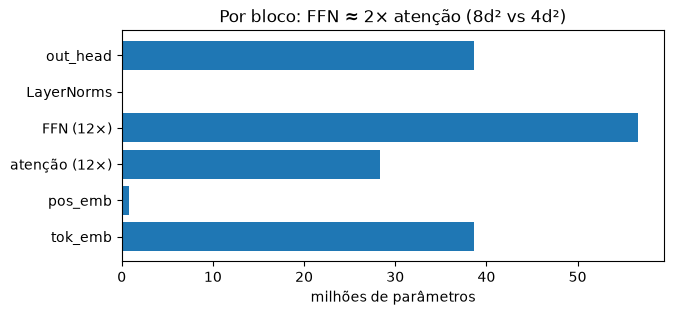

In [3]:
with torch.device("meta"):
    m = GPTModel({**GPT_CONFIG_124M, "qkv_bias": True})
partes = {
    "tok_emb": m.tok_emb.weight.numel(),
    "pos_emb": m.pos_emb.weight.numel(),
    "atenção (12×)": sum(p.numel() for b in m.trf_blocks for p in b.att.parameters()),
    "FFN (12×)": sum(p.numel() for b in m.trf_blocks for p in b.ff.parameters()),
    "LayerNorms": sum(p.numel() for b in m.trf_blocks for n in (b.norm1, b.norm2) for p in n.parameters())
                  + sum(p.numel() for p in m.final_norm.parameters()),
    "out_head": m.out_head.weight.numel(),
}
plt.figure(figsize=(7, 3))
plt.barh(list(partes), [v / 1e6 for v in partes.values()])
plt.xlabel("milhões de parâmetros"); plt.title("Por bloco: FFN ≈ 2× atenção (8d² vs 4d²)")
plt.show()

## 3. 🔧 Escalando por 3

In [4]:
FATOR = 3  # 🔧
base = GPT_CONFIG_124M
escalas = {
    "GPT-2 small": base,
    f"emb_dim × {FATOR}": {**base, "emb_dim": base["emb_dim"] * FATOR, "n_heads": base["n_heads"] * FATOR},
    f"n_layers × {FATOR}": {**base, "n_layers": base["n_layers"] * FATOR},
    f"tudo × {FATOR}": {**base, "emb_dim": base["emb_dim"] * FATOR, "n_heads": base["n_heads"] * FATOR,
                         "n_layers": base["n_layers"] * FATOR},
    "GPT-3 175B": {**base, "emb_dim": 12288, "n_heads": 96, "n_layers": 96, "context_length": 2048},
}
pd.DataFrame({k: contar(v) for k, v in escalas.items()}).T.round(1)

,params (M),sem out_head (M),embeddings (M),blocos (M),float32 (GB),treino Adam ≈ (GB)
GPT-2 small,163.0,124.4,39.4,85.0,0.7,2.6
emb_dim × 3,998.6,882.8,118.2,764.7,4.0,16.0
n_layers × 3,333.1,294.5,39.4,255.1,1.3,5.3
tudo × 3,2528.0,2412.2,118.2,2294.1,10.1,40.4
GPT-3 175B,175218.3,174600.7,642.7,173958.0,700.9,2803.5


- **Largura × 3 → blocos × 9** (os pesos são matrizes d×d: custo quadrático em `emb_dim`).
- **Profundidade × 3 → blocos × 3** (linear em `n_layers`).
- **GPT-3** é *o mesmo código* com outros números (+ atenção esparsa alternada, que omitimos): 175 bilhões de parâmetros,
  ~700 GB só em float32 e ~2,8 TB para treinar com Adam. Escalar o código é trivial; escalar dados, GPUs e engenharia não.

## 4. Viés (bias) e gradiente
### 4a. O *termo* de viés: o `+ b` em `y = Wx + b`

In [5]:
torch.manual_seed(123)
pequeno = GPTModel({**GPT_CONFIG_124M, "emb_dim": 64, "n_heads": 4, "n_layers": 2, "context_length": 32, "qkv_bias": True})
vieses = [(n, p.numel()) for n, p in pequeno.named_parameters() if n.endswith("bias") or n.endswith("shift")]
for n, k in vieses[:10]:
    print(f"{n:40s} {k}")
print(f"\n{len(vieses)} vetores de viés | GPT-2 usa qkv_bias=True; Llama e a maioria dos modelos novos removem quase todos")

trf_blocks.0.att.W_query.bias            64
trf_blocks.0.att.W_key.bias              64
trf_blocks.0.att.W_value.bias            64
trf_blocks.0.att.out_proj.bias           64
trf_blocks.0.ff.layers.0.bias            256
trf_blocks.0.ff.layers.2.bias            64
trf_blocks.0.norm1.shift                 64
trf_blocks.0.norm2.shift                 64
trf_blocks.1.att.W_query.bias            64
trf_blocks.1.att.W_key.bias              64

17 vetores de viés | GPT-2 usa qkv_bias=True; Llama e a maioria dos modelos novos removem quase todos


### 4b. O gradiente: quanto cada peso deve mudar para reduzir a loss
Aparece no `loss.backward()` — é o que o otimizador usa no `optimizer.step()`.

antes do backward: None


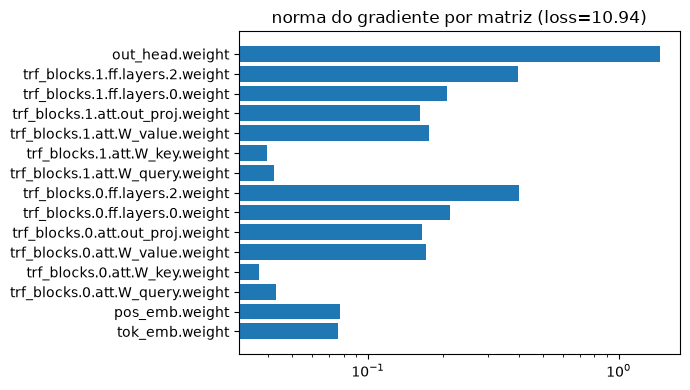

In [6]:
x = torch.randint(0, 50257, (2, 16))
loss = torch.nn.functional.cross_entropy(pequeno(x[:, :-1]).flatten(0, 1), x[:, 1:].flatten())
print("antes do backward:", pequeno.trf_blocks[0].att.W_query.weight.grad)
loss.backward()
normas = {n: p.grad.norm().item() for n, p in pequeno.named_parameters() if p.grad is not None and p.dim() == 2}
plt.figure(figsize=(7, 4))
plt.barh(list(normas), list(normas.values()))
plt.xscale("log"); plt.title(f"norma do gradiente por matriz (loss={loss.item():.2f})")
plt.tight_layout(); plt.show()

### 4c. O *outro* viés: o que o modelo aprendeu dos dados
O pré-treino absorve padrões (e preconceitos) do texto da internet. Veja o GPT-2 real:

In [7]:
gpt2, cfg = load_gpt2("124M")
gpt2.to(device)
he, she = bpe.encode(" he")[0], bpe.encode(" she")[0]
for profissao in ["nurse", "engineer", "teacher", "CEO", "secretary", "doctor"]:
    ids = torch.tensor([bpe.encode(f"The {profissao} said that")], device=device)
    with torch.no_grad():
        p = torch.softmax(gpt2(ids)[0, -1], -1)
    print(f"{profissao:10s} P(he)={p[he]:.3f}  P(she)={p[she]:.3f}")

nurse      P(he)=0.029  P(she)=0.149
engineer   P(he)=0.069  P(she)=0.008
teacher    P(he)=0.098  P(she)=0.122
CEO        P(he)=0.092  P(she)=0.009
secretary  P(he)=0.061  P(she)=0.033
doctor     P(he)=0.127  P(she)=0.060


Esse viés entra **nos dados de pré-treino**, e é mitigado (não eliminado) no fine-tuning / alinhamento.

## 5. 🔧 small vs medium gerando texto

In [8]:
from llms_from_scratch.ch05 import generate, text_to_token_ids, token_ids_to_text

prompt = "The most important idea in machine learning is"
tamanhos = ["124M", "355M"] if COMPARAR_355M else ["124M"]
for tam in tamanhos:
    m, c = load_gpt2(tam)
    m.to(device)
    torch.manual_seed(123)
    out = generate(m, text_to_token_ids(prompt, bpe).to(device), 40, c["context_length"], temperature=0.8, top_k=40)
    print(f"[{tam}] {token_ids_to_text(out, bpe)}\n")

[124M] The most important idea in machine learning is that your results can be represented by a series of discrete mathematical equations. In this way, the more you know, the easier it is to predict a given problem as it is likely to develop in the



## 6. Outras famílias usam a mesma base?
Sim — praticamente todo LLM atual é um **Transformer só-decoder** como o nosso, com trocas de peças:

| | GPT-2 (2019) | GPT-3 (2020) | Llama 2/3 | Qwen3 / Gemma 3 |
|---|---|---|---|---|
| normalização | LayerNorm (pre-norm) | LayerNorm | **RMSNorm** | RMSNorm (+ QK-norm) |
| posição | embedding aprendido | aprendido | **RoPE** | RoPE |
| FFN | GELU | GELU | **SwiGLU** | SwiGLU / GeGLU |
| atenção | multi-head | + esparsa alternada | **GQA** | GQA (+ janela deslizante no Gemma) |
| bias | sim | sim | **não** | não |
| contexto | 1024 | 2048 | 4k → 128k | 32k → 128k+ |

O repositório converte **este mesmo código** em Llama passo a passo: `ch05/07_gpt_to_llama/`
(e Qwen3, Gemma 3, OLMo 3 em `ch05/11_qwen3`, `12_gemma3`, `13_olmo3`).

**GPT-4, GPT-5 e os modelos da Anthropic (Claude):** arquitetura, nº de parâmetros e dados **não são divulgados**.
O que é público: são Transformers decoder, multimodais, com contexto longo e treinados com RLHF/alinhamento.
Números como "GPT-4 = 1,8T com MoE" circulam, mas são **rumores sem confirmação oficial** — não usar como fato.
Para ver a mesma receita em escala com pesos abertos: Llama 3, Qwen3, DeepSeek-V3 (MoE, 671B totais / 37B ativos).